# Laboratorio 2

## Desarrollo de una herramienta analítica usando paquetes especializados para análisis de datos en Python

Para el desarrollo de esta actividad puedes utilizar cualquier librería externa. Te recomendamos leer por completo el enunciado del laboratorio antes de comenzar, de forma que tengas claro el propósito global de la actividad y puedas desarrollar tu solución apuntando a él desde el inicio.

Al desarrollar este laboratorio pondrás a prueba tus habilidades para:

1. Identificar y abordar preguntas de negocio y de *analytics*.
2. Leer datos desde archivos y almacenarlos utilizando métodos de librerías especializadas.
3. Explorar, modificar, limpiar y unir objetos tablas de datos.
4. Implementar análisis combinando métricas descriptivas, visualización, filtrado y agrupación.
5. Implementar análisis basado en modelos estadísticos o de *machine learning*.

##  Contexto: desigualdad y factores de éxito en pruebas Saber 11 en Colombia

El ICFES es el Instituto Colombiano para el Fomento de la Educación Superior y está adscrito al Ministerio de Educación a nivel nacional. Como parte de sus funciones, el ICFES administra las pruebas Saber 11, las cuales evalúan a todos los estudiantes del país al final de su educación secundaria. El examen contiene preguntas que evalúan una variedad de áreas del conocimiento (ej., matemáticas, física, inglés, etc.) y se lleva a cabo dos veces al año, ajustándose a los diferentes calendarios académicos que siguen las instituciones educativas. Al momento de inscribirse a las pruebas, los estudiantes diligencian un formulario que recoge información sociodemográfica y relacionada con la institución a la que pertenecen. El fin es obtener información con respecto al desempeño de los estudiantes en la prueba y de sus características.

Al igual que otros países de la región, Colombia tiene grandes retos en términos de desigualdad, particularmente en el contexto de educación primaria y secundaria. Por esta razón, para el Estado colombiano es muy valioso el amplio registro de datos que el ICFES genera alrededor de las pruebas Saber 11, pues con ellos se pueden generar análisis sobre la calidad de la educación en el país y eventualmente dar lugar a recomendaciones sobre políticas públicas. En particular, la problemática a abordar en este caso de estudio es la desigualdad y factores de éxito en las pruebas Saber 11. 

Los objetivos de este caso de estudio son:

* Entender el contenido de los archivos de datos proporcionados sobre las pruebas Saber 11, generar un reporte acerca de sus características principales y seleccionar las partes de dicho contenido que podrían ser relevantes para el análisis.


* Identificar características de las variables de interés y relaciones entre ellas, por ejemplo, a través de agrupación, visualizaciones y estadísticas descriptivas.


* Proponer un modelo que busque relacionar las variables de interés con el desempeño de los estudiantes y concluir acerca de los posibles hallazgos que se podrían reportar para el *stakeholder*.


* Generar una herramienta que permita a un usuario interactuar con alguno de los parámetros del análisis realizado de forma relevante en el contexto del problema.

## Fase 1: obtener e inspeccionar archivos

En esta fase te harás una idea general del contenido de los datos y generarás un reporte al respecto (ej., imprimiendo mensajes, presentando tablas de resumen, etc.). Además, seleccionarás un segmento de los datos que consideres útil para realizar tu análisis.

Pautas generales:

* Utilizar una librería especializada para leer los archivos de datos y agregarlos según sea necesario (ej., utilizando los métodos `append` o `concat` si eliges cargarlos utilizando la librería `pandas`).
* Inspeccionar el archivo a partir de sus encabezados, columnas y descripciones de las variables según su tipo (ej., numéricas, categóricas).
* Declarar una estructura de datos (ej., una lista) para almacenar un subconjunto de variables que puedan ser relevantes para la problemática de interés.

Preguntas guía:

* ¿Qué dimensiones tienen los datos?
* ¿Con cuántos años y periodos de evaluación se cuenta?
* ¿Cuáles variables pueden ser de interés para la problemática planteada?
* ¿Qué porcentaje de datos faltantes o no válidos hay en las columnas de interés? ¿Qué planteas para manejarlos?

In [1]:
import pandas as pd

df1 = pd.read_csv("Archivos/Examen_Saber_11_20211.txt", sep=";", encoding="utf-8")
df2 = pd.read_csv("Archivos/Examen_Saber_11_20212.txt", sep=";", encoding="utf-8")

df = pd.concat([df1, df2], ignore_index=True)


print("\nAños/periodos disponibles en 'periodo':")
print(df['periodo'].value_counts())



C:\Users\Samuel\AppData\Local\Temp\ipykernel_18556\1329543417.py:3: DtypeWarning: Columns (4,5,6,7,13,14,15,16,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("Archivos/Examen_Saber_11_20211.txt", sep=";", encoding="utf-8")
C:\Users\Samuel\AppData\Local\Temp\ipykernel_18556\1329543417.py:4: DtypeWarning: Columns (4,5,6,7,13,14,15,16,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("Archivos/Examen_Saber_11_20212.txt", sep=";", encoding="utf-8")



Años/periodos disponibles en 'periodo':
20212    606030
20211     58708
Name: periodo, dtype: int64


In [2]:
# Quitar espacios en blanco al inicio y fin de textos
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Porcentaje de datos faltantes en todas las columnas
missing_percent = df.isnull().mean() * 100

# Ordenar de mayor a menor
missing_percent_sorted = missing_percent.sort_values(ascending=False)

print("\nPorcentaje de datos faltantes por columna:")
print(missing_percent_sorted)





Porcentaje de datos faltantes por columna:
estu_etnia                 93.301872
cole_bilingue              30.566328
fami_numlibros             22.870364
fami_comelechederivados    21.205046
fami_estratovivienda       20.814366
                             ...    
estu_discapacidad           0.000000
estu_fechanacimiento        0.000000
estu_consecutivo            0.000000
estu_nacionalidad           0.000000
periodo                     0.000000
Length: 85, dtype: float64


## Fase 2: identificar características y relaciones en las variables

En esta fase realizarás análisis descriptivo para identificar posibles patrones o relaciones entre las variables de interés para la problemática planteada. Además, expondrás estadísticas descriptivas y visualizaciones para concluir al respecto de los patrones y las relaciones identificadas. Finalmente, elegirás el segmento de los datos sobre el cual profundizarás con tu análisis (este puede ser, o no, igual al seleccionado anteriormente).

Pautas generales:

* Calcular estadísticas descriptivas básicas (por lo menos, media/mediana y varianza/desviación) para cada variable sociodemográfica relevante en el contexto del problema.
* Utilizar librerías especializadas (ej., `matplotlib`, `seaborn`, etc.) para inspeccionar visualmente variables de interés. Los métodos `distplot`, `pairplot`, `boxplot`, o `violinplot`, entre otros, pueden ser útiles.
* Utilizar el método `groupby` de `pandas`, en conjunto con métodos de visualización, puede proveer evidencia del impacto de las variables sociodemográficas de interés sobre el desempeño de los estudiantes en la prueba.

Preguntas guía:

* ¿Hay patrones de interés en las distribuciones de las variables o en las relaciones entre ellas?
* ¿Consideras que existe algún impacto significativo de variables sociodemográficas en los puntajes globales o por área?
* ¿Sobre cuáles variables harías un análisis más profundo?

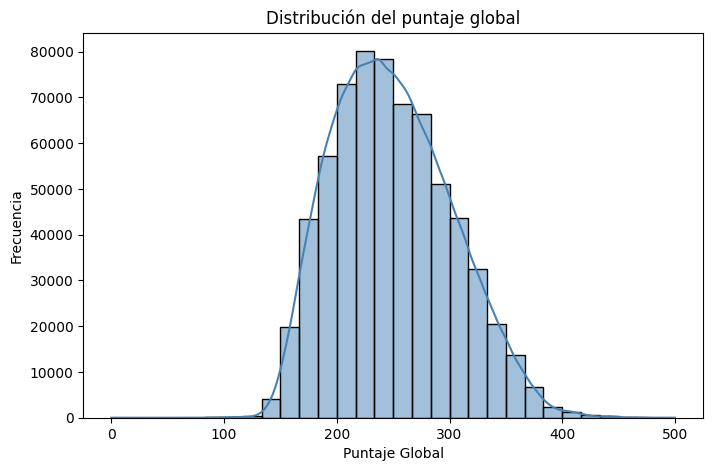

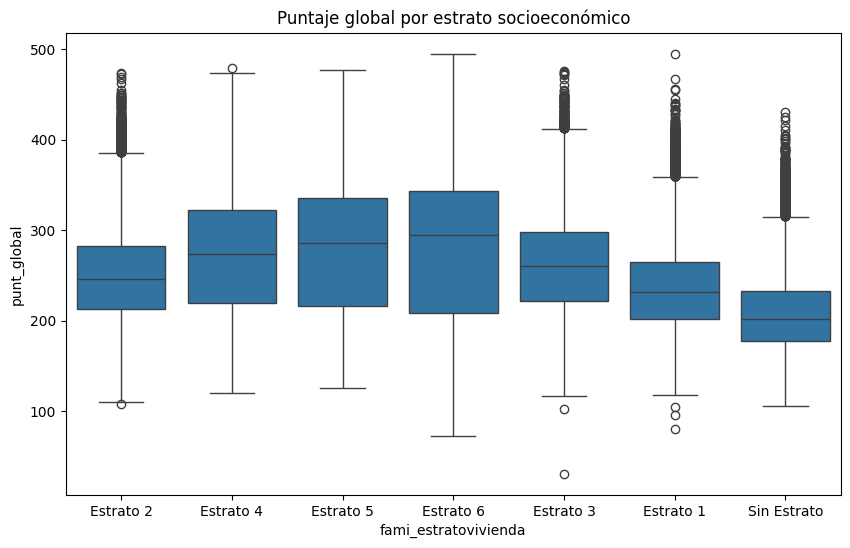

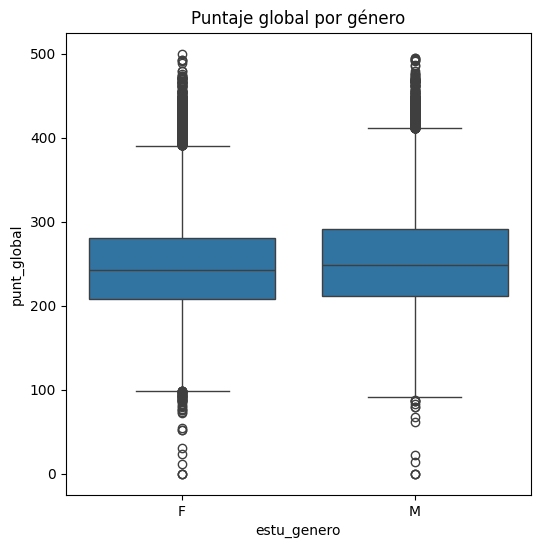

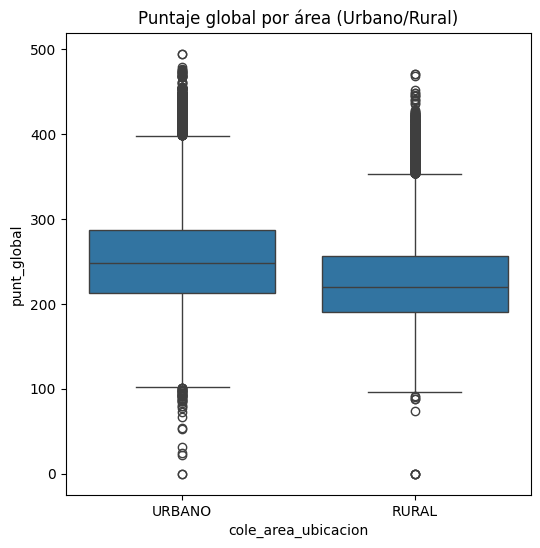

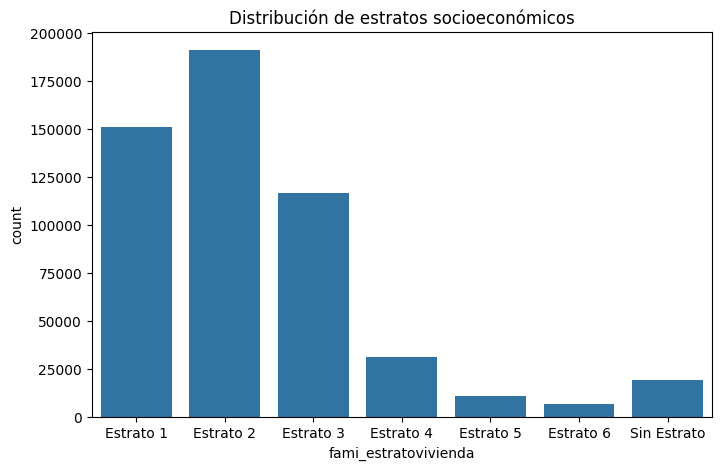

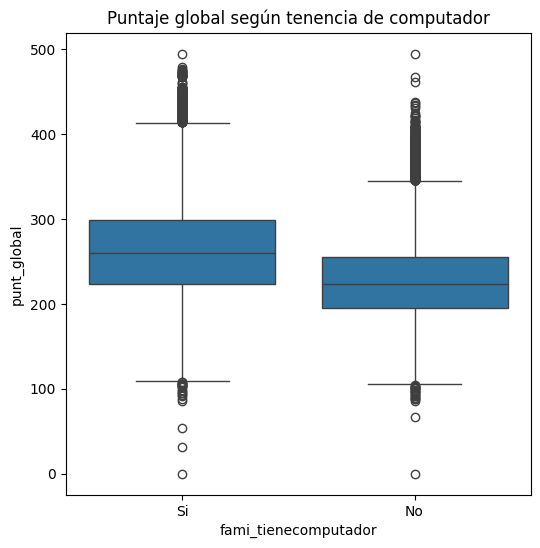

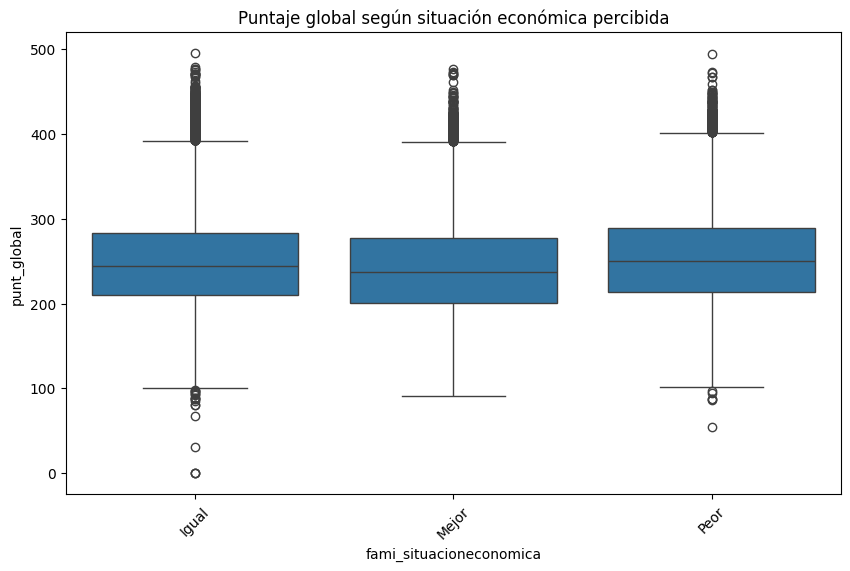

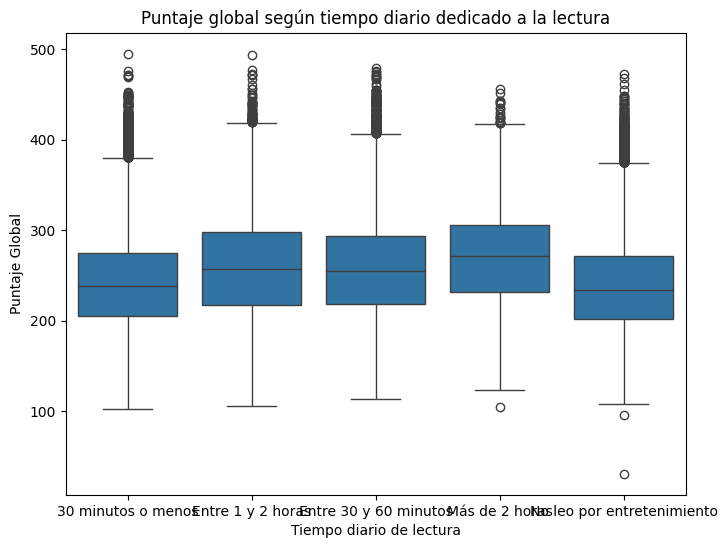


romedio de puntaje global por estrato socioeconómico:
fami_estratovivienda
Estrato 1      235.560561
Estrato 2      248.670769
Estrato 3      260.934744
Estrato 4      271.557072
Estrato 5      277.771634
Estrato 6      279.621259
Sin Estrato    209.922366
Name: punt_global, dtype: float64

 Promedio de puntaje global por nivel educativo de la madre:
fami_educacionmadre
Postgrado                               310.435151
Educación profesional completa          276.907919
Educación profesional incompleta        269.278696
Técnica o tecnológica completa          263.764029
No sabe                                 257.952628
Técnica o tecnológica incompleta        255.377328
Secundaria (Bachillerato) completa      245.515155
Secundaria (Bachillerato) incompleta    235.754446
No Aplica                               231.262447
Primaria completa                       230.205859
Primaria incompleta                     225.022470
Ninguno                                 208.752099
Name: punt_glo

,Variable,Tipo
0,punt_global,Numérica
1,fami_estratovivienda,Categórica
2,fami_educacionmadre,Categórica
3,fami_educacionpadre,Categórica
4,fami_tienecomputador,Categórica
5,fami_tieneinternet,Categórica
6,fami_numlibros,Numérica/Categórica
7,fami_tieneautomovil,Categórica
8,fami_personashogar,Numérica
9,fami_situacioneconomica,Categórica


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. selección de variables relevantes 
cols_relevantes = [
    'punt_global',  # variable objetivo
    'fami_estratovivienda','fami_educacionmadre','fami_educacionpadre',
    'fami_tienecomputador','fami_tieneinternet','fami_numlibros',
    'fami_tieneautomovil','fami_personashogar','fami_situacioneconomica',
    'estu_genero','cole_area_ubicacion','cole_naturaleza','cole_caracter',
    'estu_dedicacioninternet','estu_dedicacionlecturadiaria','estu_depto_presentacion','cole_jornada','cole_calendario',
    'estu_inse_individual',      
    'estu_nse_individual',       
    'cole_bilingue',            
    'estu_horassemanatrabaja',   
    'estu_repite'                
]

df_relevante = df[cols_relevantes].copy()


# === 3. Distribución del puntaje global ===
plt.figure(figsize=(8,5))
sns.histplot(df_relevante['punt_global'], bins=30, kde=True, color='steelblue')
plt.title('Distribución del puntaje global')
plt.xlabel('Puntaje Global')
plt.ylabel('Frecuencia')
plt.show()

# === 4. Boxplots  ===
plt.figure(figsize=(10,6))
sns.boxplot(x='fami_estratovivienda', y='punt_global', data=df_relevante)
plt.title('Puntaje global por estrato socioeconómico')
plt.show()

plt.figure(figsize=(6,6))
sns.boxplot(x='estu_genero', y='punt_global', data=df_relevante)
plt.title('Puntaje global por género')
plt.show()

plt.figure(figsize=(6,6))
sns.boxplot(x='cole_area_ubicacion', y='punt_global', data=df_relevante)
plt.title('Puntaje global por área (Urbano/Rural)')
plt.show()

# === Distribución de estratos socioeconómicos ===
plt.figure(figsize=(8,5))
sns.countplot(x='fami_estratovivienda', data=df_relevante, order=sorted(df_relevante['fami_estratovivienda'].dropna().unique()))
plt.title('Distribución de estratos socioeconómicos')
plt.show()

# === Puntaje global vs tenencia de computador ===
plt.figure(figsize=(6,6))
sns.boxplot(x='fami_tienecomputador', y='punt_global', data=df_relevante)
plt.title('Puntaje global según tenencia de computador')
plt.show()

# === Puntaje global vs situación económica percibida ===
plt.figure(figsize=(10,6))
sns.boxplot(x='fami_situacioneconomica', y='punt_global', data=df_relevante)
plt.title('Puntaje global según situación económica percibida')
plt.xticks(rotation=45)
plt.show()

# Comparar tiempo de lectura diaria y puntaje global
plt.figure(figsize=(8,6))
sns.boxplot(x='estu_dedicacionlecturadiaria', y='punt_global', data=df_relevante, order=sorted(df_relevante['estu_dedicacionlecturadiaria'].dropna().unique()))
plt.title('Puntaje global según tiempo diario dedicado a la lectura')
plt.xlabel('Tiempo diario de lectura')
plt.ylabel('Puntaje Global')
plt.show()


# === 5. Groupby para ver patrones ===
print("\nromedio de puntaje global por estrato socioeconómico:")
print(df_relevante.groupby('fami_estratovivienda')['punt_global'].mean().sort_index())

print("\n Promedio de puntaje global por nivel educativo de la madre:")
print(df_relevante.groupby('fami_educacionmadre')['punt_global'].mean().sort_values(ascending=False))


# === 6. Tabla resumen de variables seleccionadas ===
info_vars = pd.DataFrame({
    'Variable': cols_relevantes,
    'Tipo': [
        'Numérica',
        'Categórica','Categórica','Categórica',
        'Categórica','Categórica','Numérica/Categórica',
        'Categórica','Numérica','Categórica',
        'Categórica','Categórica','Categórica','Categórica',
        'Categórica','Categórica', 'Categórica',
        'Categórica','Categórica',
        'Numérica','Numérica',
        'Categórica','Categórica','Categórica'
    ]
})
print("\nVariables seleccionadas y su tipo:")
display(info_vars)


# Limpiar datos

In [4]:
# === Porcentaje de valores faltantes solo en las variables seleccionadas ===
faltantes = df_relevante.isna().mean() * 100
faltantes = faltantes.sort_values(ascending=False)

print(" Porcentaje de valores faltantes por variable seleccionada:")

faltantes_df = pd.DataFrame({
    'Variable': faltantes.index,
    'Porcentaje faltante (%)': faltantes.values.round(2)
})
display(faltantes_df)


 Porcentaje de valores faltantes por variable seleccionada:


,Variable,Porcentaje faltante (%)
0,cole_bilingue,30.57
1,fami_numlibros,22.87
2,fami_estratovivienda,20.81
3,estu_dedicacioninternet,20.56
4,estu_dedicacionlecturadiaria,20.38
5,fami_tieneinternet,20.32
6,fami_educacionmadre,20.24
7,fami_educacionpadre,20.24
8,cole_caracter,19.02
9,fami_tieneautomovil,18.88


# Manejo de nulos

In [5]:

# Lista de variables categóricas 
vars_categoricas = [
    'fami_estratovivienda','fami_educacionmadre','fami_educacionpadre',
    'fami_tienecomputador','fami_tieneinternet','fami_tieneautomovil',
    'fami_situacioneconomica','cole_caracter','cole_area_ubicacion',
    'cole_naturaleza','estu_genero','estu_dedicacioninternet','estu_dedicacionlecturadiaria','fami_numlibros','fami_personashogar','estu_depto_presentacion','cole_jornada','cole_calendario',
    'cole_bilingue','estu_horassemanatrabaja','estu_repite'
]

# Lista de variables numéricas (
vars_numericas = ['estu_inse_individual', 'estu_nse_individual']

df_relevante['fami_estratovivienda'] = df_relevante['fami_estratovivienda'].replace('Sin Estrato', 'Sin dato')

# Rellenar categóricas con "Sin dato"
for col in vars_categoricas:
    df_relevante[col] = df_relevante[col].fillna('Sin dato')

# Rellenar numéricas con mediana
for col in vars_numericas:
    df_relevante[col] = df_relevante[col].fillna(df_relevante[col].median())


print("Valores faltantes después de la imputación:")
print(df_relevante.isna().sum())


Valores faltantes después de la imputación:
punt_global                     0
fami_estratovivienda            0
fami_educacionmadre             0
fami_educacionpadre             0
fami_tienecomputador            0
fami_tieneinternet              0
fami_numlibros                  0
fami_tieneautomovil             0
fami_personashogar              0
fami_situacioneconomica         0
estu_genero                     0
cole_area_ubicacion             0
cole_naturaleza                 0
cole_caracter                   0
estu_dedicacioninternet         0
estu_dedicacionlecturadiaria    0
estu_depto_presentacion         0
cole_jornada                    0
cole_calendario                 0
estu_inse_individual            0
estu_nse_individual             0
cole_bilingue                   0
estu_horassemanatrabaja         0
estu_repite                     0
dtype: int64


## Cambio de categoricas a labelencoding y one-hot-encoding

In [6]:

from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np



# Variables para LABEL ENCODING (solo categóricas)
label_vars = [
    'fami_estratovivienda',
    'fami_educacionmadre',
    'fami_educacionpadre',
    'fami_numlibros',
    'estu_dedicacioninternet',
    'estu_dedicacionlecturadiaria',
    'estu_depto_presentacion',  
    'cole_bilingue',
    'estu_horassemanatrabaja',
    'estu_repite'
]

# Variables numéricas (no necesitan label encoding)
numeric_vars = ['fami_personashogar', 'estu_inse_individual', 'estu_nse_individual']

# Variables para one-hot encoding (solo las que tienen pocas categorías)
onehot_vars = [
    'fami_tienecomputador',
    'fami_tieneinternet',
    'fami_tieneautomovil',
    'fami_situacioneconomica',
    'estu_genero',
    'cole_area_ubicacion',
    'cole_naturaleza',
    'cole_caracter',
    'cole_jornada',        
    'cole_calendario'
]

# Mapeo de rangos a valores numéricos (completo según los datos reales)
mapa_personashogar = {
    "Sin dato": 0,   #
    "1 a 2": 1,
    "3 a 4": 2,
    "5 a 6": 3,
    "7 a 8": 4,      
    "9 o más": 5     
}

# Aplicar mapeo y convertir NaN a 0
df_relevante["fami_personashogar"] = df_relevante["fami_personashogar"].map(mapa_personashogar).fillna(0)


# 2. Label Encoding 

def label_encode_df(df, cols):
    df_copy = df.copy()
    for col in cols:
        # Solo procesar si la columna no es numérica
        if col not in ['fami_personashogar', 'estu_inse_individual', 'estu_nse_individual']:
            # Convertir todo a string para evitar errores de tipo
            df_copy[col] = df_copy[col].astype(str)
            df_copy[col] = df_copy[col].replace('nan', 'Sin dato')
            
            le = LabelEncoder()
            le.fit(df_copy[col])
            df_copy[col] = le.transform(df_copy[col])
    return df_copy


# 3. Aplicar encoding 


# Paso 1: Imputar variables numéricas
df_relevante['estu_inse_individual'] = df_relevante['estu_inse_individual'].fillna(df_relevante['estu_inse_individual'].median())
df_relevante['estu_nse_individual'] = df_relevante['estu_nse_individual'].fillna(df_relevante['estu_nse_individual'].median())

# Paso 2: LabelEncoder en categóricas
df_encoded = label_encode_df(df_relevante, label_vars)

# Paso 3: OneHot en nominales
df_encoded = pd.get_dummies(df_encoded, columns=onehot_vars, drop_first=True)

print("Forma final:", df_encoded.shape)
print("Primeras filas:")
display(df_encoded.head(15))





Forma final: (664738, 42)
Primeras filas:


,punt_global,fami_estratovivienda,fami_educacionmadre,fami_educacionpadre,fami_numlibros,fami_personashogar,estu_dedicacioninternet,estu_dedicacionlecturadiaria,estu_depto_presentacion,estu_inse_individual,...,cole_caracter_TÉCNICO/ACADÉMICO,cole_jornada_MAÑANA,cole_jornada_NOCHE,cole_jornada_SABATINA,cole_jornada_Sin dato,cole_jornada_TARDE,cole_jornada_UNICA,cole_calendario_B,cole_calendario_OTRO,cole_calendario_Sin dato
0,308,1,8,11,0,1,3,0,31,57.191147,...,0,0,0,0,0,0,0,1,0,0
1,208,6,10,10,4,0,5,5,25,56.380276,...,1,0,0,0,0,0,1,0,0,0
2,371,3,0,5,2,2,3,1,4,78.666115,...,0,1,0,0,0,0,0,1,0,0
3,190,1,8,9,0,2,3,4,30,56.060024,...,0,0,0,1,0,0,0,0,0,0
4,321,1,5,0,2,2,1,2,31,72.677086,...,0,0,0,0,0,0,0,1,0,0
5,333,4,11,0,3,1,3,2,4,69.706917,...,0,0,0,0,0,0,1,0,1,0
6,214,4,10,4,0,2,1,4,3,61.529499,...,0,0,0,0,0,0,0,1,0,0
7,308,5,1,8,4,3,3,0,4,65.802147,...,0,0,0,0,0,0,0,1,0,0
8,255,3,0,12,2,2,1,2,31,66.694427,...,0,0,0,0,0,0,0,1,0,0
9,273,1,11,11,1,3,1,1,31,62.578632,...,0,0,0,0,0,0,1,1,0,0


## Correlacion

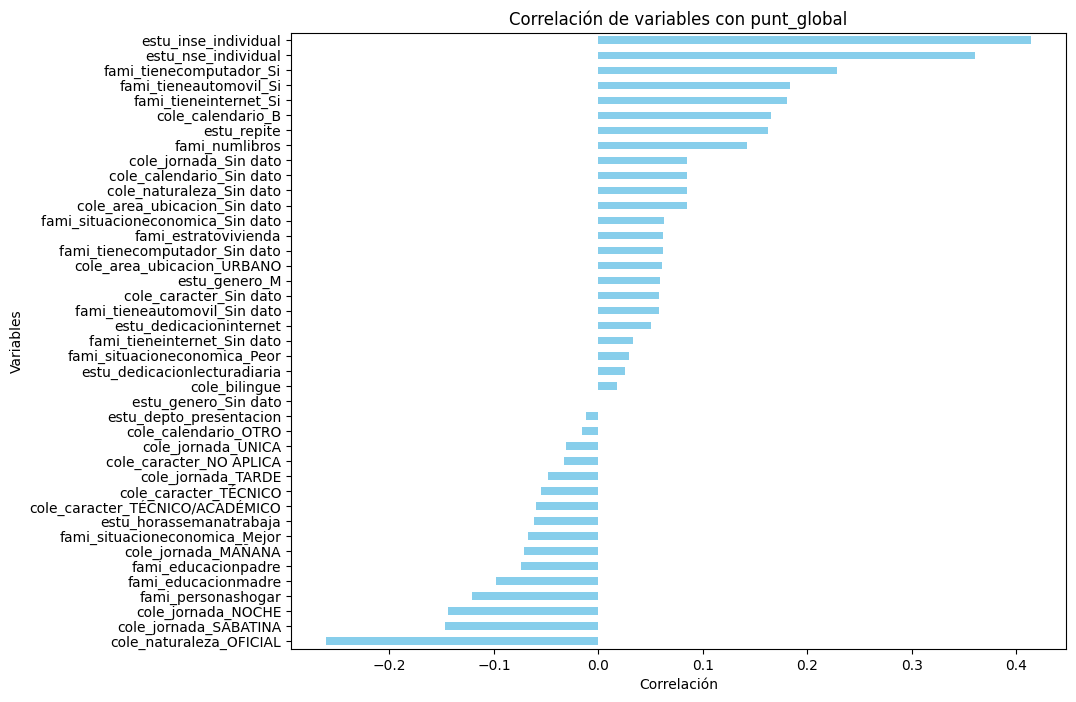

In [7]:

import matplotlib.pyplot as plt

# 1. Calcular la matriz de correlación
corr_matrix = df_encoded.corr(numeric_only=True)

# 3. Mostrar correlación de cada variable con el target
corr_with_target = corr_matrix["punt_global"].sort_values(ascending=False)


# Calcular correlación solo con la variable objetivo
corr_with_target = corr_matrix["punt_global"].drop("punt_global").sort_values(ascending=False)

# Gráfico de barras
plt.figure(figsize=(10,8))
corr_with_target.plot(kind="barh", color="skyblue")
plt.title("Correlación de variables con punt_global")
plt.xlabel("Correlación")
plt.ylabel("Variables")
plt.gca().invert_yaxis()  # Para que la variable más correlacionada quede arriba
plt.show()



## Fase 3: abordar relación variables-desempeño a través de un modelo

En esta fase propondrás, implementarás y reportarás el desempeño de uno o más modelos (al menos uno predictivo) que busquen explicar las relaciones entre factores sociodemográficos y el desempeño en la prueba. Además, concluirás con respecto a la validez de al menos un modelo y los posibles hallazgos que se podrían reportar para el *stakeholder*.

Pautas generales:

* Seleccionar variables y proponer modelos acordes a estas y al contexto del problema.
* Utilizar librerías especializadas (ej., `statsmodels`, `sklearn`, etc.) para indagar sobre los aspectos que contribuyen al éxito de los estudiantes. Los módulos correspondientes a regresión lineal y regresión logística pueden ser útiles.
* Asegurar el cumplimiento de los supuestos y buenas prácticas de cada modelo.
* Utilizar las métricas de evaluación de desempeño (disponibles en las librerías especilizadas), para concluir sobre la validez de los modelos propuestos.

Preguntas guía:

* ¿Existe algún sub-conjunto de variables socio-demográficas que explique razonablemente bien el desempeño de los estudiantes en la prueba?

### dividir variables dejar la Y sola

In [8]:
X = df_encoded.drop("punt_global", axis=1)  # features
y = df_encoded["punt_global"]               # target


### identificar si las variables son int o categoricas

In [9]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["uint8"]).columns

print("Numéricas:", num_cols.tolist())
print("Categóricas:", cat_cols.tolist())


Numéricas: ['fami_personashogar', 'estu_inse_individual', 'estu_nse_individual']
Categóricas: ['fami_tienecomputador_Si', 'fami_tienecomputador_Sin dato', 'fami_tieneinternet_Si', 'fami_tieneinternet_Sin dato', 'fami_tieneautomovil_Si', 'fami_tieneautomovil_Sin dato', 'fami_situacioneconomica_Mejor', 'fami_situacioneconomica_Peor', 'fami_situacioneconomica_Sin dato', 'estu_genero_M', 'estu_genero_Sin dato', 'cole_area_ubicacion_Sin dato', 'cole_area_ubicacion_URBANO', 'cole_naturaleza_OFICIAL', 'cole_naturaleza_Sin dato', 'cole_caracter_NO APLICA', 'cole_caracter_Sin dato', 'cole_caracter_TÉCNICO', 'cole_caracter_TÉCNICO/ACADÉMICO', 'cole_jornada_MAÑANA', 'cole_jornada_NOCHE', 'cole_jornada_SABATINA', 'cole_jornada_Sin dato', 'cole_jornada_TARDE', 'cole_jornada_UNICA', 'cole_calendario_B', 'cole_calendario_OTRO', 'cole_calendario_Sin dato']


### Definir el preprocesado

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols), 
        ("cat", SimpleImputer(strategy="most_frequent"), cat_cols)
    ]
)


### dividir datos

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### ver cuantos datos tenemos de entrenamiento test y totales

In [12]:
print(f"Total de datos: {X.shape[0]}")
print(f"Datos de entrenamiento (train): {X_train.shape[0]}")
print(f"Datos de prueba (test): {X_test.shape[0]}")


Total de datos: 664738
Datos de entrenamiento (train): 531790
Datos de prueba (test): 132948


### Crear pipeine con el random forest

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42, n_jobs=-1))
])

### hiperparametros con GridSearchCV

In [14]:

from sklearn.model_selection import GridSearchCV

param_grid = {
    "regressor__n_estimators": [50, 310],   # árboles
    "regressor__max_depth": [None, 10, 15], # profundidad
    "regressor__max_features": [5, 10, 15], # features por split
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=2,
    n_jobs=4,
    scoring="r2"
)

### Entrenar modelo

In [15]:
grid_search.fit(X_train, y_train)

print("Mejores parámetros encontrados:")
print(grid_search.best_params_)

Mejores parámetros encontrados:
{'regressor__max_depth': 15, 'regressor__max_features': 10, 'regressor__n_estimators': 310}


### evaluar el random forest

In [16]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

best_model = grid_search.best_estimator_

y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

print("=== Entrenamiento ===")
print(f"R²:   {r2_score(y_train, y_pred_train):.4f}")
print(f"MSE:  {mean_squared_error(y_train, y_pred_train):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"MAE:  {mean_absolute_error(y_train, y_pred_train):.4f}")

print("\n=== Test ===")
print(f"R²:   {r2_score(y_test, y_pred_test):.4f}")
print(f"MSE:  {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_test):.4f}")


=== Entrenamiento ===
R²:   0.2976
MSE:  1954.4613
RMSE: 44.2093
MAE:  35.4604

=== Test ===
R²:   0.2618
MSE:  2045.7170
RMSE: 45.2296
MAE:  36.3235


In [17]:
import joblib
import os

# Crear directorio si no existe
model_dir = "Archivos"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Guardar el modelo entrenado
model_path = os.path.join(model_dir, "random_forest_model.pkl")
joblib.dump(best_model, model_path)

print(f"Modelo guardado exitosamente en: {model_path}")
print(f"Tamaño del archivo: {os.path.getsize(model_path) / (1024*1024):.2f} MB")

# También guardar información del modelo
model_info = {
    'best_params': grid_search.best_params_,
    'best_score': grid_search.best_score_,
    'feature_names': X.columns.tolist(),
    'model_type': 'RandomForestRegressor'
}

info_path = os.path.join(model_dir, "model_info.pkl")
joblib.dump(model_info, info_path)

print(f"Información del modelo guardada en: {info_path}")

Modelo guardado exitosamente en: Archivos\random_forest_model.pkl
Tamaño del archivo: 360.89 MB
Información del modelo guardada en: Archivos\model_info.pkl


In [ ]:
def load_saved_model():
    
    import joblib
    import os
    
    model_path = os.path.join("Archivos", "random_forest_model.pkl")
    info_path = os.path.join("Archivos", "model_info.pkl")
    
    if os.path.exists(model_path) and os.path.exists(info_path)
        model = joblib.load(model_path)
        model_info = joblib.load(info_path)
        
        
        return model, model_info
    else:
        print("No se encontró un modelo guardado. Debes entrenar el modelo primero.")
        return None, None


## Fase 4

Deberás elegir y realizar una de las dos alternativas que se encuentran a continuación.

### Alternativa 1: desarrollar una herramienta interactiva de análisis

En esta fase desarrollarás, a partir de alguno de los análisis realizados, una herramienta interactiva que sea relevante en el contexto del problema, acompañada de las instrucciones necesarias para que un usuario la pueda utilizar.

Pautas generales:

* Seleccionar uno de los análisis previos que pueda verse enriquecido con alguna característica de interactividad.
* Seleccionar el/los parámetro(s) que el usuario podrá cambiar.
* Desarrollar las funciones que se deben ejecutar con cada acción del usuario.
* Utilizar una librería especializada (ej., `ipywidgets`, `panel`, etc.) para implementar la herramienta.

Preguntas guía:

* ¿Cuál o cuáles preguntas podrá hacerle el usuario a la herramienta y cómo aporta la respuesta al análisis?
* ¿Qué aprendizajes clave puede explorar u obtener el usuario con esta herramienta?

### Alternativa 2: registrar en bases de datos relacionales con PySpark

En esta fase desarrollarás, a partir de alguno de los análisis realizados, un _script_ que sea relevante en el contexto del problema, acompañado de las instrucciones necesarias para que un usuario lo pueda ejecutar.

Pautas generales:

* Cargar en una base de datos relacional (tipo SQL) el segmento de los datos sobre el cual profundizaste en tu anális, utilizando una tabla distinta para cada categoría de campos. Por ejemplo, una categoría puedes ser información del colegio; en cuyo caso, una tabla debería contener un registro único para cada colegio y todos los campos asociados.

* Los campos, a excepción de los identificadores, deben existir en un única tabla.

* Cada registro debe existir una única vez en su respectiva tabla.

* Cada registro debe tener un identificador único en su tabla, el cual establece una relación entre tablas.

* Seleccionar uno de los modelos predictivos implementados.

* Crear en la base de datos relacional una tabla que contenga únicamente los identificadores del registro y la predicción de la variable de respuesta hecha por el modelo.

* Desarrollar _queries_ de SQL según las siguientes indicaciones y concluir acerca de los resultados:
    * Un _query_ que seleccione todos registros y los agregue en una única tabla. Para esto debes relacionar las tablas por su identificador, utilizando el método `JOIN`.
    * Un _query_ que contenga el puntaje promedio de los estudiantes, agrupado por año y por colegio.
    * Distintos _queries_ que calculen medidas de error de predicción del modelo a partir de los datos reales y las predicciones respectivas. Debes reportar el error para cada registro, el error total de los registros de entrenamiento y el error total de los registros de prueba.
    * Haz dos _queries_ adicionales que resulten interesantes.

Preguntas guía:

* ¿Cómo aporta la segmentación de los datos en categorías de campos al manejo de los datos?
* ¿Qué filtros y agrupaciones podemos aplicar sobre los datos con el fin de obtener información relevante?

## Referencias

*  J. VanderPlas (2016) *Python Data Science Handbook: Essential Tools for Working with Data* O'Reilly Media, Inc.
*  scikit-learn developers . (2020). Demo of DBSCAN clustering algorithm. 11 Diciembre 2020, de scikit-learn <br> https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html#sphx-glr-auto-examples-cluster-plot-dbscan-py

## Créditos

__Autores__: Camilo Hernando Gómez Castro, Alejandro Mantilla Redondo, Jose Fernando Barrera de Plaza, Diego Alejandro Cely Gómez.

__Fecha última actualización__: 29/09/2022